Eigen vectors and values:

In [1]:
import numpy as np

mat = np.array([[4, 2], [1, 3]])
a, b, c, d = mat[0, 0], mat[0, 1], mat[1, 0], mat[1, 1]
# (a, b), (c, d) = mat -- can do

coeff = [1, -(a + d), (a * d) - (b * c)]
evs = np.roots(coeff)
print('Eigenvalues: ', evs)

I = np.array([[1, 0], [0, 1]])

for i in evs:
    l = mat - (I * i)

    evr = [1, 0]
    if l[0, 1] != 0:
        evr[1] = -(l[0, 0] / l[0, 1])
    elif l[1, 0] != 0:
        evr[1] = -(l[1, 0] / l[1, 1])
    print('Eigenvector for', i, ':', evr)

Eigenvalues:  [5. 2.]
Eigenvector for 5.0 : [1, 0.5]
Eigenvector for 2.0 : [1, -1.0]


(OR)

In [2]:
import numpy as np

mat = np.array([[4, 2], [1, 3]])
a, b, c, d = mat[0, 0], mat[0, 1], mat[1, 0], mat[1, 1]
# (a, b), (c, d) = mat -- can do

coeff = [1, -(a + d), (a * d) - (b * c)]
evs = np.roots(coeff)
print('Eigenvalues: ', evs)

I = np.array([[1, 0], [0, 1]])
v1 = evs[0]
v2 = evs[1]
vv1 = mat -(I*v1)
vv2 = mat -(I*v2)
print(vv1[0][1],-vv1[0][0])
print(vv2[0][1],-vv2[0][0])

Eigenvalues:  [5. 2.]
2.0 1.0
2.0 -2.0


PCA:

In [3]:
import numpy as np

data = np.array([[2, 1], [4, 3], [5, 4]])
n_rows = len(data)
n_cols = len(data[0])

mean = [sum(data[j][i] for j in range(n_rows)) / n_rows for i in range(n_cols)]

centered = data - mean

print(centered)

cov = [[0] * n_cols for _ in range(n_cols)]

for i in range(n_cols):
    for j in range(n_cols):
        for k in range(n_rows):
            cov[i][j] += centered[k][i] * centered[k][j] / (n_rows - 1)
            cov[i][j] = round(cov[i][j], 2)
cov = np.array(cov)
print(cov)

a, b, c, d = cov[0, 0], cov[0, 1], cov[1, 0], cov[1, 1]

coeff = [1, -(a + d), a * d - b * c]
l = np.roots(coeff)
L = max(l)

I = np.array([[1, 0], [0, 1]])
cov_L = cov - I * L
Evr = [1, 0]
Evr[1] = -(cov_L[0, 0] / cov_L[0, 1])

print(Evr)

projected = [0] * n_rows
for i in range(n_rows):
    for j in range(n_cols):
        projected[i] += centered[i][j] * Evr[j]

print(projected)


[[-1.66666667 -1.66666667]
 [ 0.33333333  0.33333333]
 [ 1.33333333  1.33333333]]
[[2.34 2.34]
 [2.34 2.34]]
[1, 1.0]
[-3.333333333333333, 0.666666666666667, 2.666666666666667]


Gradient Descent:

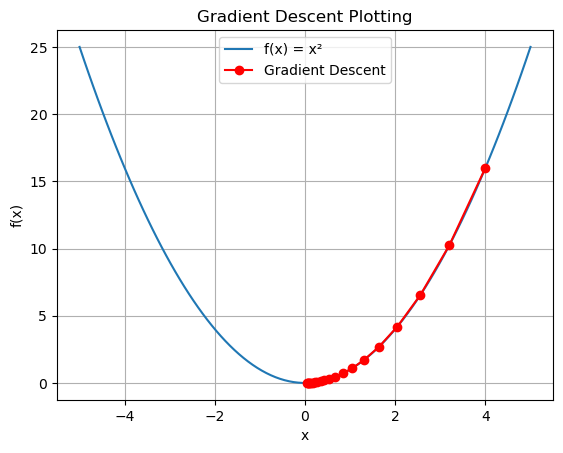

Final x: 0.05
Path: [4, 3.2, 2.56, 2.05, 1.64, 1.31, 1.05, 0.84, 0.67, 0.54, 0.43, 0.34, 0.27, 0.22, 0.18, 0.14, 0.11, 0.09, 0.07, 0.06, 0.05]


In [4]:
import numpy as np
def f(x):
    return x**2
def grad(x):
    return 2 * x

x = 4
learning_rate = 0.1
steps = 20
path = [x]
for _ in range(steps):
    x = x - learning_rate * grad(x)
    path.append(x)

import numpy as np
def f(x):
    return x**2
x_values = np.linspace(-5, 5, 100)  # Range for f(x)
y_values = [f(x) for x in x_values]  # f(x) values
path_y = [f(x) for x in path]  # f(x) along path

import matplotlib.pyplot as plt

x_values = np.linspace(-5, 5, 100)
y_values = [f(x) for x in x_values]
path_y = [f(x) for x in path]
plt.plot(x_values, y_values, label="f(x) = x²")
plt.plot(path, path_y, "ro-", label="Gradient Descent")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent Plotting")
plt.legend()
plt.grid(True)
plt.show()

print("Final x:", round(path[-1], 2))
print("Path:", [round(x, 2) for x in path])
